Sample Dataset:
   Weather   Soil Temperature Humidity    Wind Fertilizer CropType  Season  \
0   Rainy  Moist         Hot     High    Weak        Yes     Corn    Rabi   
1   Sunny    Dry        Cool      Low    Weak        Yes     Rice    Rabi   
2   Rainy  Moist        Mild   Medium  Strong        Yes     Rice  Kharif   
3   Rainy  Moist        Cool     High  Strong        Yes     Rice  Kharif   
4   Sunny  Moist        Cool     High    Weak         No     Rice  Kharif   

  Irrigate  
0       No  
1      Yes  
2       No  
3       No  
4       No  
Decision Tree Accuracy: 0.7777777777777778
Random Forest Accuracy: 0.7222222222222222

Decision Tree Confusion Matrix:
             Pred No  Pred Yes
Actual No         8         3
Actual Yes        1         6

Random Forest Confusion Matrix:
             Pred No  Pred Yes
Actual No         9         2
Actual Yes        3         4


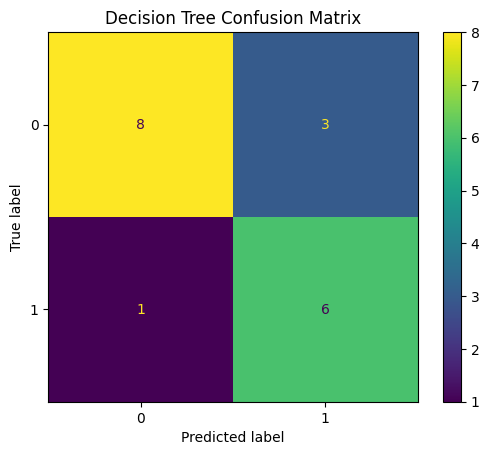

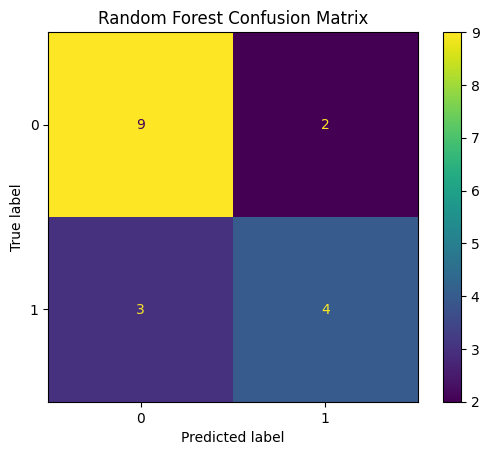


Cross Validation Accuracy: 
Decision Tree: 0.7833333333333334
Random Forest: 0.7833333333333334

Feature Importance:
        Feature  Importance
1         Soil    0.332566
3     Humidity    0.130952
7       Season    0.113627
0      Weather    0.113024
5   Fertilizer    0.084339
4         Wind    0.079553
2  Temperature    0.075823
6     CropType    0.070117


In [2]:
#1.Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

#2.Generate larger farming dataset

np.random.seed(42)
n_samples=60
data = {
    'Weather':np.random.choice(['Sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['Dry','Moist','Wet'],n_samples),
    'Temperature':np.random.choice(['Hot','Mild','Cool'],n_samples),
    'Humidity':np.random.choice(['High','Medium','Low'],n_samples),
    'Wind':np.random.choice(['Strong','Weak'],n_samples),
    'Fertilizer':np.random.choice(['Yes','No'],n_samples),
    'CropType':np.random.choice(['Wheat',' Rice','Corn'],n_samples),
    'Season':np.random.choice(['Kharif','Rabi','Summer'],n_samples)
}

df=pd.DataFrame(data)

#3.Create Target Variable(Rule-based for realism)

def irrigation_rule(row):
  if row['Soil']=='Dry' and row['Weather']!='Rainy':
     return 'Yes'
  elif row['Soil']=='Wet':
     return 'No'
  elif row['Humidity']=='High' and row['Weather']=='Rainy':
     return 'No'
  else:
    return np.random.choice(['Yes','No'])

df['Irrigate'] = df.apply(irrigation_rule,axis=1)

print("Sample Dataset:\n",df.head())

#4.Encode Categorical variables

le_dict = {}

for column in df.columns:
  le = LabelEncoder()
  df[column] = le.fit_transform(df[column])
  le_dict[column] = le


#5.Split Features and Target

X = df.drop('Irrigate',axis=1)
y = df['Irrigate']

#============================================
#6.Train-Test Split (STRATIFIED)
#============================================
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

#============================================
#7.Decision Tree Model
#============================================
dt_model = DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt = dt_model.predict(X_test)

#============================================
#8.Random Forest Model
#============================================

rf_model = RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    random_state=42
)

rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)


#9.Accuracy Evaluation

dt_accuracy = accuracy_score(y_test,y_pred_dt)
rf_accuracy = accuracy_score(y_test,y_pred_rf)

print("Decision Tree Accuracy:",dt_accuracy)
print("Random Forest Accuracy:",rf_accuracy)

#10.Confusion Matrix(FIXED+MEANINGFUL)

cm_dt = confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf = confusion_matrix(y_test,y_pred_rf,labels=[0,1])

cm_dt_rf = pd.DataFrame(cm_dt,index=['Actual No','Actual Yes'],columns=['Pred No','Pred Yes'])
cm_rf_df = pd.DataFrame(cm_rf,index=['Actual No','Actual Yes'],columns=['Pred No','Pred Yes'])

print("\nDecision Tree Confusion Matrix:\n",cm_dt_rf)
print("\nRandom Forest Confusion Matrix:\n",cm_rf_df)


#11.Confusion Matrix Visualization

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf,labels=[0,1])
plt.title("Random Forest Confusion Matrix")
plt.show()

#12.Cross Validation

dt_cv = cross_val_score(dt_model,X,y,cv=5)
rf_cv = cross_val_score(rf_model,X,y,cv=5)

print("\nCross Validation Accuracy: ")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())

#13.Feature Importance(Random Forest)

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_}).sort_values(by='Importance',ascending=False)
print("\nFeature Importance:\n",importance)
